# Sensorimotor EEG ERD Analysis

Decoding motor intent from sensorimotor EEG using spectral and time–frequency analysis.

**Goal:** Quantify event-related desynchronization (ERD) in the mu (8–12 Hz) and beta (13–30 Hz) bands over sensorimotor cortex (C3/Cz/C4) during motor task events.

#
## Load Dataset (EEGBCI / PhysioNet)

We use the PhysioNet EEG Motor Movement/Imagery dataset via MNE's EEGBCI loader.  
The dataset is stored in EDF format (standard EEG file format). Event markers include:

- **T0**: rest
- **T1, T2**: task classes (depends on run; commonly left vs right motor imagery)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import re
from mne.datasets import eegbci
from mne.io import read_raw_edf

subject = 1
runs = [6]  # common motor imagery run

files = eegbci.load_data(subject, runs)
raw = read_raw_edf(files[0], preload=True, verbose=False)

raw

/Users/keeratkaur/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MB, data loaded>

## Basic Inspection / Exploratory Visualization

We inspect metadata and visualize a short segment of raw EEG to confirm signal quality.

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: 3 items (dict)
>
Number of channels: 64
First 15 channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.']
Using matplotlib as 2D backend.


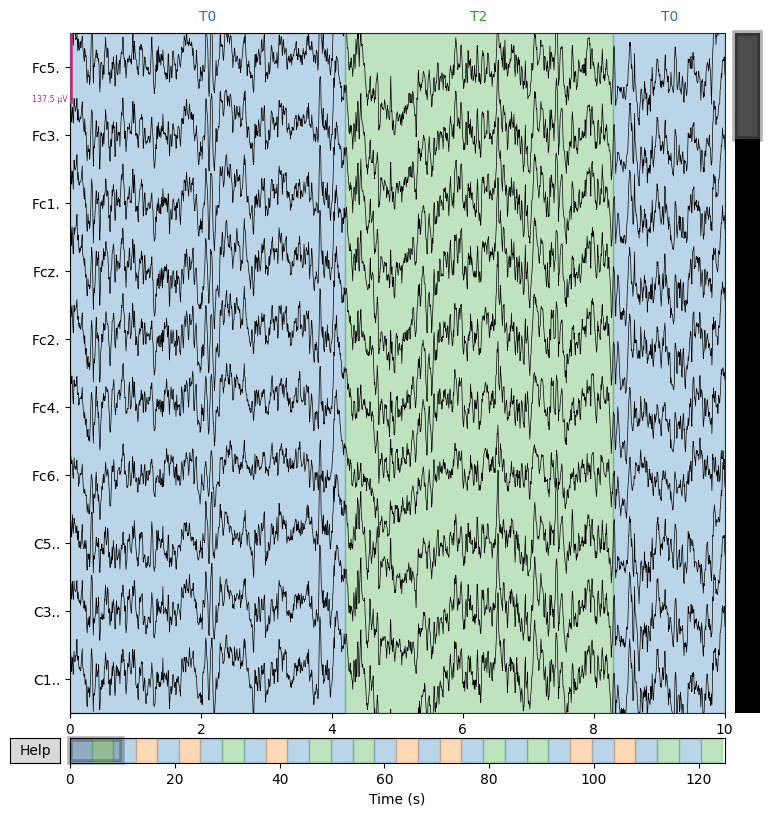

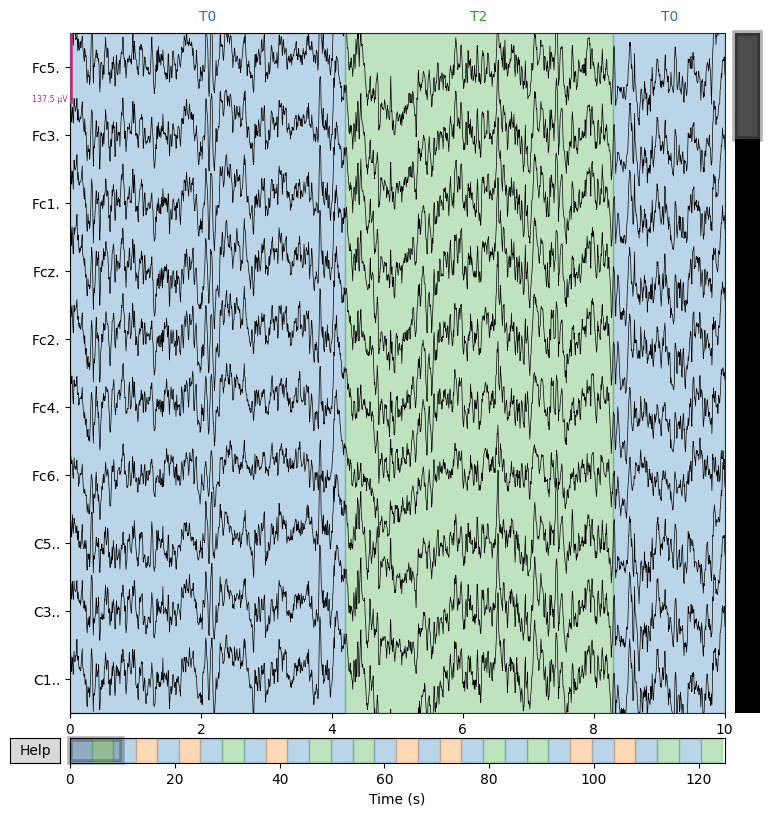

In [3]:
print(raw.info)
print("Number of channels:", len(raw.ch_names))
print("First 15 channels:", raw.ch_names[:15])

raw.plot(n_channels=10, duration=10, scalings="auto")

## Channel Name Cleanup + Montage

Some channel names in EEGBCI include punctuation (e.g., `C3.`).  
We remove dots/spaces so channels match standard 10–20 naming, then attach a 10–20 montage for scalp locations.

In [4]:
raw.rename_channels(lambda ch: re.sub(r'[\.\s]', '', ch))
raw.set_montage("standard_1020", on_missing="ignore")

# confirm ROI channels exist
roi = ["C3", "Cz", "C4"]
print("ROI present:", {ch: (ch in raw.ch_names) for ch in roi})

ROI present: {'C3': True, 'Cz': True, 'C4': True}


## Preprocessing: Bandpass Filter (1–40 Hz)

We bandpass filter to remove slow drifts (<1 Hz) and high-frequency noise (>40 Hz), while preserving mu and beta rhythms.

In [5]:
raw_filt = raw.copy().filter(l_freq=1.0, h_freq=40.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



## Event Extraction

We extract events from annotations. The EEGBCI dataset typically uses T0/T1/T2 markers.

In [6]:
events, event_id = mne.events_from_annotations(raw_filt)
print("event_id mapping:", event_id)
events[:10]

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
event_id mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


array([[   0,    0,    1],
       [ 672,    0,    3],
       [1328,    0,    1],
       [2000,    0,    2],
       [2656,    0,    1],
       [3328,    0,    2],
       [3984,    0,    1],
       [4656,    0,    3],
       [5312,    0,    1],
       [5984,    0,    2]])

## Epoching Around Events

We segment the continuous EEG into epochs centered on each event.  
We use a baseline window of **-2 to -1 seconds** before the event for normalization.

In [7]:
epochs = mne.Epochs(
    raw_filt,
    events,
    event_id=event_id,
    tmin=-2.0,
    tmax=2.0,
    baseline=(-2.0, -1.0),
    picks="eeg",
    preload=True
)

epochs_T0 = epochs["T0"]
epochs_T1 = epochs["T1"]
epochs_T2 = epochs["T2"]
epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])

print("Epoch counts:", len(epochs_T0), len(epochs_T1), len(epochs_T2))

Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
1 bad epochs dropped
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
Epoch counts: 14 7 8


/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_4084/3460007673.py:15: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])


## Spectral Analysis: PSD (Welch)

We compute power spectral density (PSD) using Welch’s method to compare oscillatory power across frequencies.

Effective window size : 4.006 (s)
Effective window size : 4.006 (s)


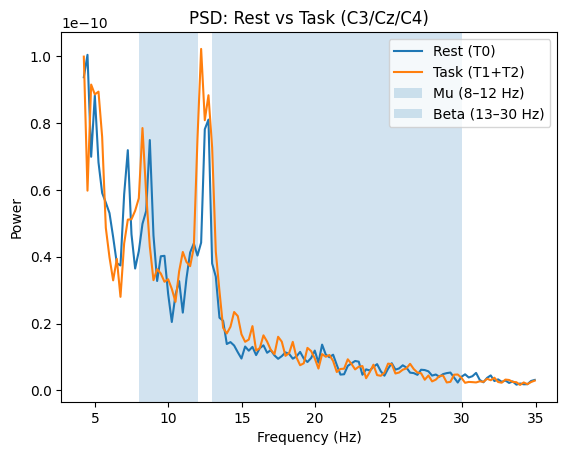

In [9]:
psd_rest = epochs_T0.copy().pick(roi).compute_psd(method="welch", fmin=4, fmax=35)
psd_task = epochs_task.copy().pick(roi).compute_psd(method="welch", fmin=4, fmax=35)

freqs = psd_rest.freqs
rest_mean = psd_rest.get_data().mean(axis=(0, 1))  # avg over epochs + channels
task_mean = psd_task.get_data().mean(axis=(0, 1))

plt.figure()
plt.plot(freqs, rest_mean, label="Rest (T0)")
plt.plot(freqs, task_mean, label="Task (T1+T2)")
plt.axvspan(8, 12, alpha=0.2, label="Mu (8–12 Hz)")
plt.axvspan(13, 30, alpha=0.2, label="Beta (13–30 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("PSD: Rest vs Task (C3/Cz/C4)")
plt.legend()
plt.show()

## Lateralization: C3 vs C4 for T1 vs T2

Motor activity is typically contralateral (left hand ↔ right hemisphere and vice-versa).  
We compare PSD at **C3 vs C4** across task classes (T1 vs T2) to look for lateralized effects.

Effective window size : 4.006 (s)
Effective window size : 4.006 (s)


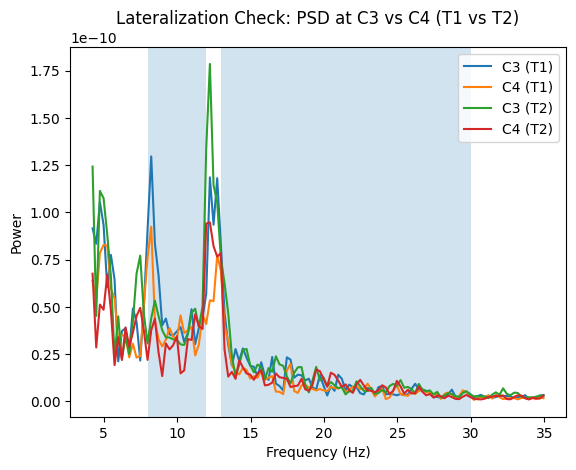

In [10]:
roi_lat = ["C3", "C4"]

psd_T1 = epochs_T1.copy().pick(roi_lat).compute_psd(method="welch", fmin=4, fmax=35)
psd_T2 = epochs_T2.copy().pick(roi_lat).compute_psd(method="welch", fmin=4, fmax=35)

freqs = psd_T1.freqs

c3_T1 = psd_T1.copy().pick("C3").get_data().mean(axis=(0, 1))
c4_T1 = psd_T1.copy().pick("C4").get_data().mean(axis=(0, 1))
c3_T2 = psd_T2.copy().pick("C3").get_data().mean(axis=(0, 1))
c4_T2 = psd_T2.copy().pick("C4").get_data().mean(axis=(0, 1))

plt.figure()
plt.plot(freqs, c3_T1, label="C3 (T1)")
plt.plot(freqs, c4_T1, label="C4 (T1)")
plt.plot(freqs, c3_T2, label="C3 (T2)")
plt.plot(freqs, c4_T2, label="C4 (T2)")
plt.axvspan(8, 12, alpha=0.2)
plt.axvspan(13, 30, alpha=0.2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Lateralization Check: PSD at C3 vs C4 (T1 vs T2)")
plt.legend()
plt.show()

## Time–Frequency Analysis (Morlet Wavelets)

We compute a time–frequency representation to visualize task-related power changes over time.
We use baseline normalization (-2 to -1 s) and log-ratio scaling.

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: logratio)


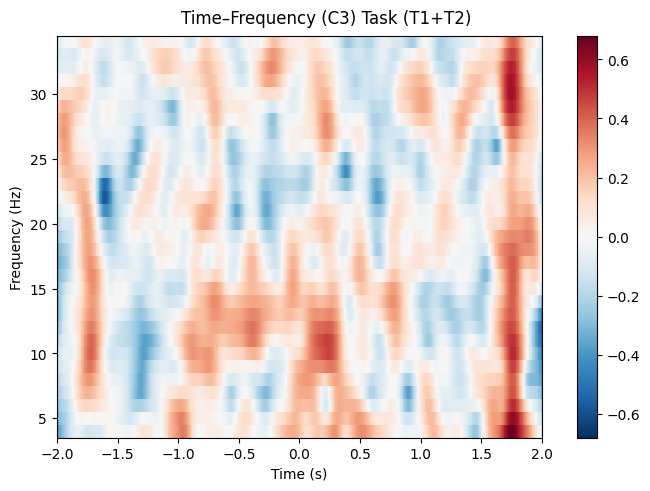

[<Figure size 640x480 with 2 Axes>]

In [11]:
power = mne.time_frequency.tfr_morlet(
    epochs_task.copy().pick(["C3"]),
    freqs=np.arange(4, 35, 1),
    n_cycles=np.arange(4, 35, 1) / 2,
    return_itc=False,
    average=True
)

power.plot(baseline=(-2, -1), mode="logratio", title="Time–Frequency (C3) Task (T1+T2)")